# minimal-fft 1/3: Why a zoomed FFT

*The problem this library solves: sampling the point-spread function of a pupil finely enough, without padding the pupil with millions of zeros.*

Series: [1. Why](01_why_zoom_fft.ipynb) · [2. What it computes](02_what_it_computes.ipynb) · [3. Benchmark](03_benchmark.ipynb)

In [1]:
import math, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from minimal_fft import zoom_fft, zoom_ifft, zoom_freq, czt

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.2),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 1.5,
    "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]),
    "image.cmap": "gray",
})
torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.14.0


## Pupil and point-spread function

Under the Fraunhofer approximation the amplitude point-spread function is the Fourier transform of the pupil function, and the intensity PSF is its modulus squared. For a clear circular pupil the intensity is the Airy pattern $I(v) = [2 J_1(v)/v]^2$ with $v = 2\pi\,\mathrm{NA}\,r/\lambda$.

We use two dimensionless coordinates: in the pupil, distances in units of the pupil radius, and in the image plane, distances in units of $\lambda/\mathrm{NA}$, written $u$. A frequency $\omega$ in radians per sample then corresponds to $u = \omega R / 2\pi$.

## Sampling with fft2

We define the pupil as a disk of radius $R = 64$ samples on an $N \times N$ grid with $N = 256$, centred at index $N//2$. `torch.fft.fft2` evaluates the spectrum at the frequencies $2\pi k/N$, so the output step is $R/N = 0.25\,\lambda/\mathrm{NA}$, while the Airy disk has radius $0.61\,\lambda/\mathrm{NA}$ and covers about two output samples. The figure shows the pupil, the PSF obtained this way and its central cut against the analytic Airy pattern.

In [2]:
N, R = 256, 64                                        # grid size and pupil radius, in samples

yy, xx = torch.meshgrid(torch.arange(N) - N // 2, torch.arange(N) - N // 2, indexing="ij")
rho = torch.sqrt(yy.to(torch.float64) ** 2 + xx.to(torch.float64) ** 2) / R
pupil = (rho <= 1.0).to(torch.complex64)              # disk of radius R, centred on index N//2

from scipy.special import j1
from mpl_toolkits.axes_grid1 import make_axes_locatable

def airy(u):
    # analytic Airy intensity, u in units of lambda/NA, normalised to 1 at u = 0
    v = 2 * np.pi * np.abs(np.asarray(u, dtype=float))
    out = np.ones_like(v)
    nz = v > 0
    out[nz] = (2 * j1(v[nz]) / v[nz]) ** 2
    return out

def norm_int(field):
    # |field|^2 normalised to its peak, as a numpy array
    I = (field.abs() ** 2).to(torch.float64).numpy()
    return I / I.max()

def show(fig, ax, img, extent, title, cmap="magma", label="$I/I_{max}$", vmax=1.0):
    im = ax.imshow(img, extent=extent, origin="lower", cmap=cmap, vmin=0.0, vmax=vmax,
                   interpolation="nearest")
    ax.set_title(title, fontsize=9.5)
    ax.grid(False)
    if label is not None:
        cax = make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.06)
        fig.colorbar(im, cax=cax, label=label)
    return im

FOV, CUT = 4.0, 2.0                                   # display field and cut range, lambda/NA
ext_pup = [-N / 2 / R, (N / 2 - 1) / R] * 2
AIRY = dict(color="0.65", lw=3.0, zorder=1, solid_capstyle="round")   # drawn underneath

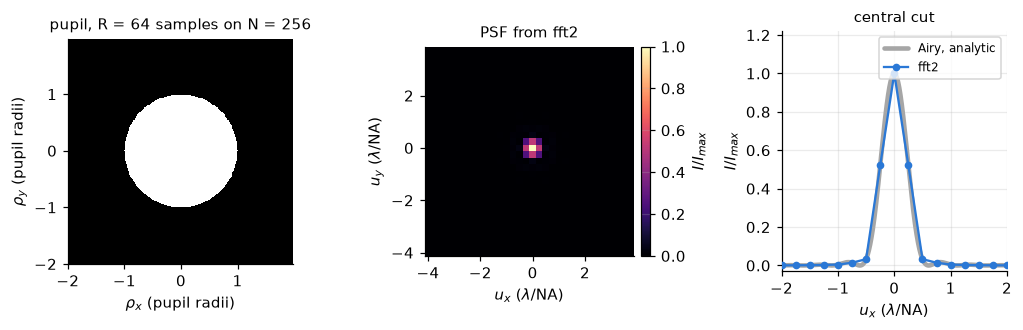

In [3]:
psf_plain = torch.fft.fftshift(torch.fft.fft2(torch.fft.ifftshift(pupil)))
I_plain = norm_int(psf_plain)
u_plain = np.arange(-N // 2, N // 2) * R / N          # lambda/NA, step R/N

c_pl = slice(N // 2 - int(FOV * N / R), N // 2 + int(FOV * N / R))
ext_pl = [u_plain[c_pl][0] - R / N / 2, u_plain[c_pl][-1] + R / N / 2] * 2
uu = np.linspace(-CUT, CUT, 2001)

fig, axes = plt.subplots(1, 3, figsize=(9.4, 3.1))
show(fig, axes[0], pupil.abs().numpy(), ext_pup, f"pupil, R = {R} samples on N = {N}",
     cmap="gray", label=None)
axes[0].set_xlabel(r"$\rho_x$ (pupil radii)"); axes[0].set_ylabel(r"$\rho_y$ (pupil radii)")
show(fig, axes[1], I_plain[c_pl, c_pl], ext_pl, "PSF from fft2")
axes[1].set_xlabel(r"$u_x$ ($\lambda$/NA)"); axes[1].set_ylabel(r"$u_y$ ($\lambda$/NA)")

axes[2].plot(uu, airy(uu), label="Airy, analytic", **AIRY)
axes[2].plot(u_plain[c_pl], I_plain[N // 2, c_pl], "o-", ms=4, color="#2a78d6",
             label="fft2", zorder=3)
axes[2].set_xlim(-CUT, CUT); axes[2].set_ylim(-0.03, 1.22)
axes[2].set_xlabel(r"$u_x$ ($\lambda$/NA)"); axes[2].set_ylabel("$I/I_{max}$")
axes[2].set_title("central cut", fontsize=9.5)
axes[2].legend(fontsize=8, loc="upper right")
fig.tight_layout(); plt.show()

## Zero-padding

The output step is fixed by the size of the array that is transformed, so it can be refined by padding the pupil with zeros to $L \times L$, which gives a step of $R/L$. We take $L = 2048$ and crop the transform back to $256 \times 256$ samples. Padding samples the same underlying transform more finely and adds no information.

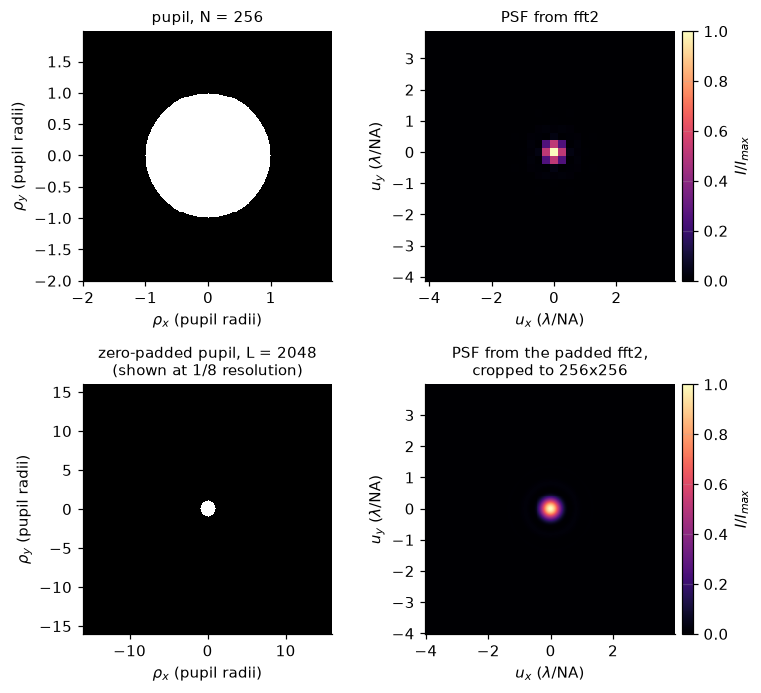

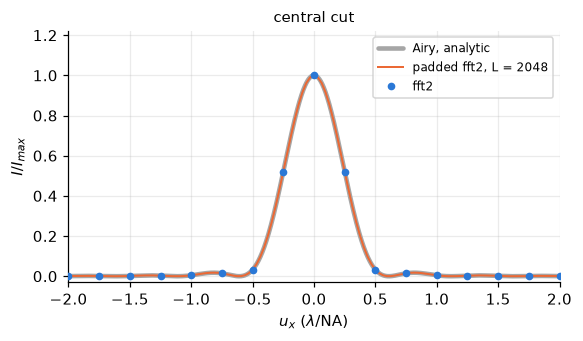

In [4]:
M, L = 256, 2048
du = R / L                                            # lambda/NA per output sample
u_out = np.arange(-M // 2, M // 2) * du

def padded_psf(pupil, L, M):
    N = pupil.shape[-1]
    o = L // 2 - N // 2                               # the pupil centre lands on index L//2
    pad = torch.zeros(*pupil.shape[:-2], L, L, dtype=pupil.dtype)
    pad[..., o:o + N, o:o + N] = pupil
    big = torch.fft.fftshift(torch.fft.fft2(torch.fft.ifftshift(pad, dim=(-2, -1))), dim=(-2, -1))
    crop = big[..., L // 2 - M // 2: L // 2 + M // 2, L // 2 - M // 2: L // 2 + M // 2]
    return crop.clone(), pad

psf_pad, pad = padded_psf(pupil, L, M)
I_pad = norm_int(psf_pad)

d = L // N                                            # display decimation for the L x L array
ext_pad = [-L / 2 / R, (L / 2 - 1) / R] * 2
ext_out = [u_out[0] - du / 2, u_out[-1] + du / 2] * 2

fig, axes = plt.subplots(2, 2, figsize=(7.2, 6.4))
show(fig, axes[0, 0], pupil.abs().numpy(), ext_pup, f"pupil, N = {N}", cmap="gray", label=None)
show(fig, axes[0, 1], I_plain[c_pl, c_pl], ext_pl, "PSF from fft2")
show(fig, axes[1, 0], pad.abs().numpy()[::d, ::d], ext_pad,
     f"zero-padded pupil, L = {L}\n(shown at 1/{d} resolution)", cmap="gray", label=None)
show(fig, axes[1, 1], I_pad, ext_out, f"PSF from the padded fft2,\ncropped to {M}x{M}")
for ax in axes[:, 0]:
    ax.set_xlabel(r"$\rho_x$ (pupil radii)"); ax.set_ylabel(r"$\rho_y$ (pupil radii)")
for ax in axes[:, 1]:
    ax.set_xlabel(r"$u_x$ ($\lambda$/NA)"); ax.set_ylabel(r"$u_y$ ($\lambda$/NA)")
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.plot(uu, airy(uu), label="Airy, analytic", **AIRY)
ax.plot(u_out, I_pad[M // 2], color="#eb6834", lw=1.3, label=f"padded fft2, L = {L}", zorder=2)
ax.plot(u_plain[c_pl], I_plain[N // 2, c_pl], "o", ms=4, color="#2a78d6", label="fft2", zorder=4)
ax.set_xlim(-CUT, CUT); ax.set_ylim(-0.03, 1.22)
ax.set_xlabel(r"$u_x$ ($\lambda$/NA)"); ax.set_ylabel("$I/I_{max}$")
ax.set_title("central cut", fontsize=9.5); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The pupil occupies a small part of the padded array and the crop discards most of the transform. The cost grows as $L^2 \log L$ while the useful output stays at $M^2$.

## Zoomed FFT

The samples kept by the crop are the frequencies $2\pi k / L$ for $k = -M/2, \dots, M/2 - 1$, which is the band $[-\pi M/L,\, \pi M/L)$ sampled at $M$ points with the right end excluded. `zoom_fft` evaluates the transform directly on such a band, with three FFTs of length $\mathrm{next\_pow2}(N + M - 1)$ per axis rather than one of length $L$, and `zoom_freq` returns the band frequencies. It normalises with `norm="ortho"` by default where `torch.fft.fft2` uses `"backward"`. The equivalence with the padded and cropped FFT holds to round-off and is checked numerically in notebook 2.

Below we ask for a field of $\pm 1.5\,\lambda/\mathrm{NA}$ on $256 \times 256$ samples and compare it with `fft2` on the same field.

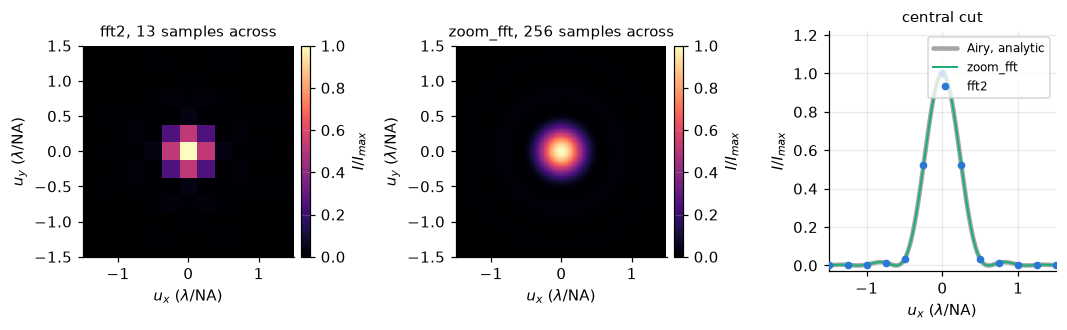

In [5]:
ZFOV, M_z = 1.5, 256                                  # field half-width (lambda/NA), samples
k_z = 2 * np.pi * ZFOV / R                            # band half-width, rad/sample
psf_zoom = zoom_fft(pupil, n_out=(M_z, M_z), k_start=-k_z, k_end=k_z,
                    dim=(-2, -1), norm="backward", center=True)
I_zoom = norm_int(psf_zoom)
step_z = 2 * ZFOV / M_z
u_z = -ZFOV + np.arange(M_z) * step_z
ext_z = [u_z[0] - step_z / 2, u_z[-1] + step_z / 2] * 2

j = int(ZFOV / (R / N))                               # fft2 samples inside the same field
c_z = slice(N // 2 - j, N // 2 + j + 1)
ext_c = [u_plain[c_z][0] - R / N / 2, u_plain[c_z][-1] + R / N / 2] * 2

fig, axes = plt.subplots(1, 3, figsize=(9.8, 3.1))
show(fig, axes[0], I_plain[c_z, c_z], ext_c, f"fft2, {2*j+1} samples across")
show(fig, axes[1], I_zoom, ext_z, f"zoom_fft, {M_z} samples across")
for ax in axes[:2]:
    ax.set_xlim(-ZFOV, ZFOV); ax.set_ylim(-ZFOV, ZFOV)
    ax.set_xlabel(r"$u_x$ ($\lambda$/NA)"); ax.set_ylabel(r"$u_y$ ($\lambda$/NA)")

uz = np.linspace(-ZFOV, ZFOV, 2001)
axes[2].plot(uz, airy(uz), label="Airy, analytic", **AIRY)
axes[2].plot(u_z, I_zoom[M_z // 2], color="#1baf7a", lw=1.3, label="zoom_fft", zorder=3)
axes[2].plot(u_plain[c_z], I_plain[N // 2, c_z], "o", ms=4, color="#2a78d6", label="fft2", zorder=4)
axes[2].set_xlim(-ZFOV, ZFOV); axes[2].set_ylim(-0.03, 1.22)
axes[2].set_xlabel(r"$u_x$ ($\lambda$/NA)"); axes[2].set_ylabel("$I/I_{max}$")
axes[2].set_title("central cut", fontsize=9.5); axes[2].legend(fontsize=8, loc="upper right")
fig.tight_layout(); plt.show()

## Other bands

The band is set by two frequencies and a sample count rather than by an array size, so it is not restricted to what padding can produce. The panels below use a step corresponding to a non-integer $L$, a rectangular output with the same step on both axes, and a band centred on the third Airy ring. Each panel is normalised to its own maximum.

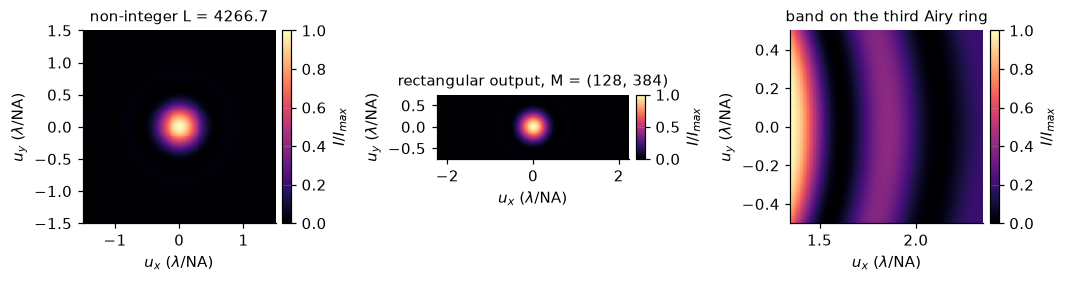

In [6]:
w_of_u = lambda x: 2 * np.pi * x / R                  # lambda/NA -> rad/sample

M_f, half_f = 200, ZFOV                               # non-integer L: any step is allowed
psf_a = zoom_fft(pupil, n_out=(M_f, M_f), k_start=-w_of_u(half_f), k_end=w_of_u(half_f),
                 dim=(-2, -1), norm="backward", center=True)
L_f = R * M_f / (2 * half_f)

M_r, step_r = (128, 384), step_z                      # rectangular output, same step on both axes
hy, hx = M_r[0] * step_r / 2, M_r[1] * step_r / 2
psf_b = zoom_fft(pupil, n_out=M_r, k_start=(-w_of_u(hy), -w_of_u(hx)),
                 k_end=(w_of_u(hy), w_of_u(hx)), dim=(-2, -1), norm="backward", center=True)

u0, hw, M_o = 11.6198 / (2 * np.pi), 0.5, 128         # third Airy ring, at v = 11.62
psf_c = zoom_fft(pupil, n_out=(M_o, M_o), k_start=(w_of_u(-hw), w_of_u(u0 - hw)),
                 k_end=(w_of_u(hw), w_of_u(u0 + hw)), dim=(-2, -1), norm="backward", center=True)

fig, axes = plt.subplots(1, 3, figsize=(9.8, 3.1))
for ax, field, extent, title in [
    (axes[0], psf_a, [-half_f, half_f] * 2, f"non-integer L = {L_f:.1f}"),
    (axes[1], psf_b, [-hx, hx, -hy, hy], f"rectangular output, M = {M_r}"),
    (axes[2], psf_c, [u0 - hw, u0 + hw, -hw, hw], "band on the third Airy ring"),
]:
    show(fig, ax, norm_int(field), extent, title)
    ax.set_xlabel(r"$u_x$ ($\lambda$/NA)"); ax.set_ylabel(r"$u_y$ ($\lambda$/NA)")
fig.tight_layout(); plt.show()

[Notebook 2](02_what_it_computes.ipynb) defines `zoom_fft`, `zoom_ifft`, `zoom_freq` and `czt`, pins the `center`, `include_end` and `norm` conventions used here, checks the equivalence with zero-padding numerically, and covers the adjoint, batching, GPU execution and autograd. [Notebook 3](03_benchmark.ipynb) measures speed, memory and accuracy against `torch.fft` and `scipy.signal.zoom_fft`, and shows where the chirp Z-transform stops being the better choice.